In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [14]:
df = pd.read_csv("BostonHousing.csv")
df.columns = df.columns.str.replace('"', '')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [15]:
X = df.drop("medv", axis=1)
y = df["medv"]                

print(X.shape, y.shape)

(506, 13) (506,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100
12/12 [==============================] - 2s 51ms/step - loss: 609.4908 - mae: 22.8412 - val_loss: 545.5452 - val_mae: 21.8961
Epoch 2/100
12/12 [==============================] - 0s 10ms/step - loss: 608.1105 - mae: 22.8300 - val_loss: 545.5064 - val_mae: 21.8974
Epoch 3/100
12/12 [==============================] - 0s 10ms/step - loss: 606.7158 - mae: 22.8159 - val_loss: 545.4377 - val_mae: 21.8985
Epoch 4/100
12/12 [==============================] - 0s 12ms/step - loss: 605.3307 - mae: 22.8019 - val_loss: 545.3695 - val_mae: 21.8988
Epoch 5/100
12/12 [==============================] - 0s 12ms/step - loss: 604.0131 - mae: 22.7891 - val_loss: 545.3370 - val_mae: 21.8994
Epoch 6/100
12/12 [==============================] - 0s 12ms/step - loss: 602.7595 - mae: 22.7787 - val_loss: 545.3071 - val_mae: 21.9009
Epoch 7/100
12/12 [==============================] - 0s 12ms/step - loss: 601.3965 - mae: 22.7641 - val_loss: 545.2677 - val_mae: 21.9013
Epoch 8/100
12/12 [===============

In [19]:
model = Sequential()

model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 1)                 14        
                                                                 
Total params: 14
Trainable params: 14
Non-trainable params: 0
_________________________________________________________________


In [20]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 [==============================] - 1s 26ms/step - loss: 619.1035 - mae: 22.9453 - val_loss: 561.4804 - val_mae: 22.1545
Epoch 2/100
21/21 [==============================] - 0s 7ms/step - loss: 616.5227 - mae: 22.9188 - val_loss: 559.8052 - val_mae: 22.1382
Epoch 3/100
21/21 [==============================] - 0s 5ms/step - loss: 614.2180 - mae: 22.9001 - val_loss: 558.0590 - val_mae: 22.1224
Epoch 4/100
21/21 [==============================] - 0s 6ms/step - loss: 611.8631 - mae: 22.8757 - val_loss: 556.4937 - val_mae: 22.1057
Epoch 5/100
21/21 [==============================] - 0s 5ms/step - loss: 609.6795 - mae: 22.8571 - val_loss: 554.7559 - val_mae: 22.0898
Epoch 6/100
21/21 [==============================] - 0s 5ms/step - loss: 607.3672 - mae: 22.8319 - val_loss: 553.1971 - val_mae: 22.0734
Epoch 7/100
21/21 [==============================] - 0s 9ms/step - loss: 605.1638 - mae: 22.8120 - val_loss: 551.5129 - val_mae: 22.0576
Epoch 8/100
21/21 [=====================

In [21]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 [==============================] - 0s 5ms/step - loss: 452.1226 - mae: 20.4826
Test Loss (MSE): 452.12261962890625
Test MAE: 20.482568740844727


In [22]:
y_pred = model.predict(X_test)

for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 [==============================] - 0s 4ms/step
Actual: 23.60 | Predicted: 4.98
Actual: 32.40 | Predicted: 7.19
Actual: 13.60 | Predicted: -3.93
Actual: 22.80 | Predicted: 3.63
Actual: 16.10 | Predicted: -2.76


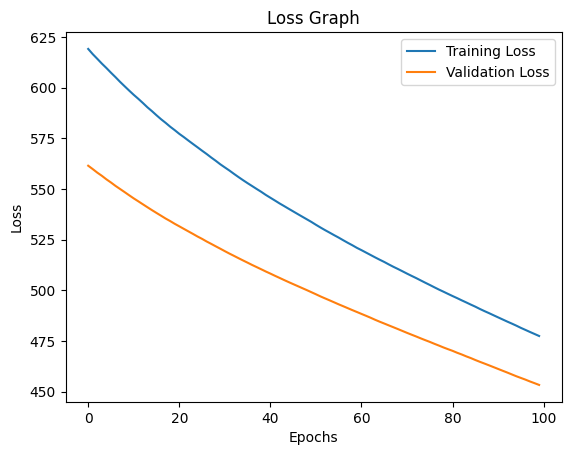

In [23]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()